# ЦВЕТОВЫЕ МОДЕЛИ И СОЗДАНИЕ И СОХРАНЕНИЕ ИЗОБРАЖЕНИЯ

In [2]:
import pandas as pd
from PIL import Image
import io

## Открываем файл

In [3]:
pic_path = "../pics/white_screen.png"

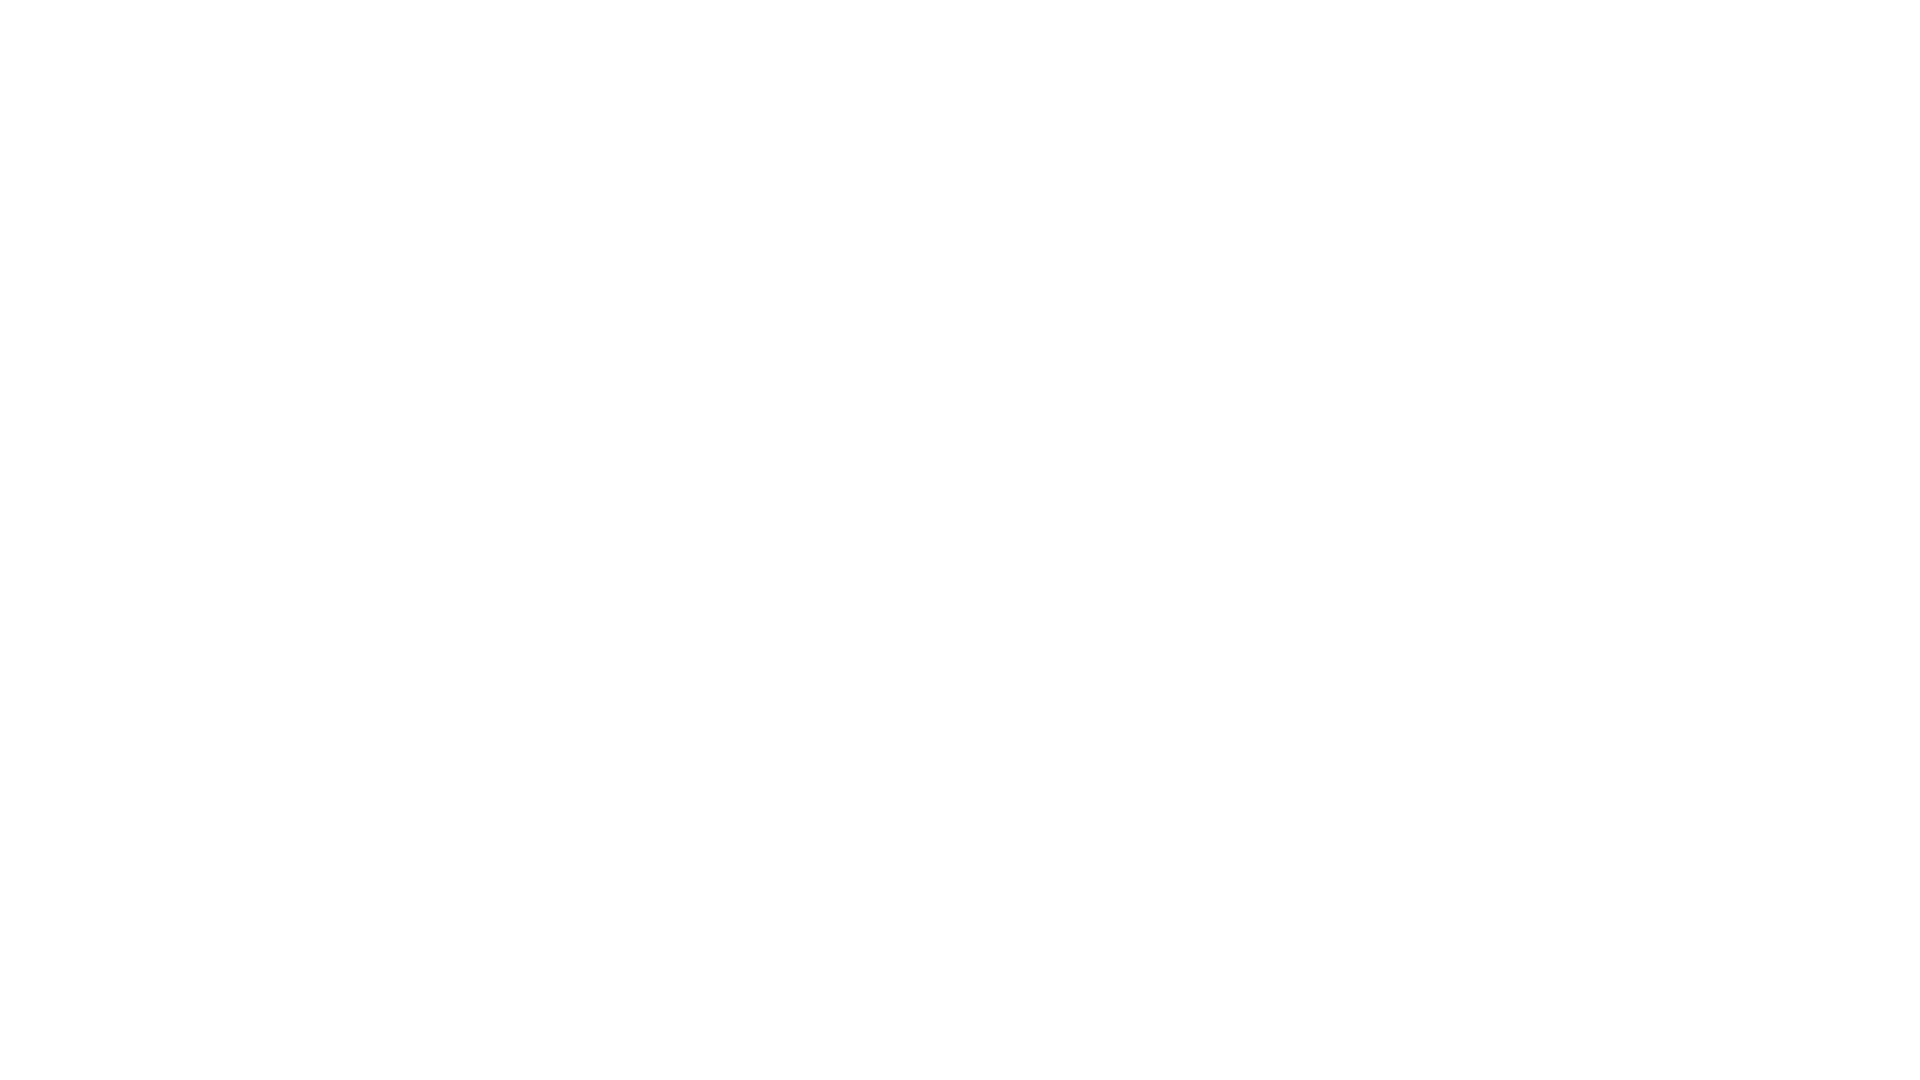

In [4]:
img = Image.open(pic_path)
img.convert("L")

In [5]:
print(img.format)

PNG


## Изменение пикселя

In [6]:
img.mode

'RGB'

In [7]:
img.size

(1920, 1080)

    w      h

Матрица изображения:

In [8]:
img_matrix = img.load()

Изменим цвет пикселя:

In [9]:
img_matrix[300, 500] = (0, 0, 0)
img.show()

Получим цвет пикселя:

In [10]:
print(img.getpixel((0,0)))      # не измененный пикксель
print(img.getpixel((300, 500))) # измененный пиксель

(255, 255, 255)
(0, 0, 0)


Изменение цвета пикселя через putpixel():

In [11]:
img.putpixel((300, 500), (0, 255, 0))
print(img.getpixel((300, 500)))

(0, 255, 0)


## Переход от одной цветовой модели изображения к другой

### RGB -> RGBA

#### с помощью split и merge:

In [12]:
R, G, B = img.split()


In [13]:
mask = Image.new(mode="L", size=img.size, color=130)   # 0 (black) <= color <= 255 (white)
img_merged = Image.merge(mode="RGBA", bands=(R,G,B,mask))
img_merged.mode

'RGBA'

In [14]:
img_merged.show()

#### с помощью convert:

In [15]:
img2 = img.convert(mode="P", matrix=None, dither=Image.FLOYDSTEINBERG, palette=Image.ADAPTIVE, colors=128)
print(img2.mode)
img2.show()

P


## Сохранение изображения

In [16]:
img.save("tmp.png")

## Создание нового изображения

Создаем белый квадрат:

In [17]:
new_img = Image.new(mode="RGB", size=(100,100), color=(255,255,255))
new_img.show()

Зеленый квадрат:

In [18]:
new_img1 = Image.new(mode="RGB", size=(100,100), color="green")
new_img1.show()

Квадрат произвольного цвета в hex:

In [19]:
new_img2 = Image.new(mode="RGB", size=(100,100), color="#ccccff")
new_img2.show()

Цвет - каналы в % + перекраска в один цвет: 

In [20]:
new_img3 = Image.new(mode="RGB", size=(320,240), color="rgb(70%, 10%, 40%)")
new_img3.show()

for w in range(0, 320):
    for h in range(0, 240):
        img.putpixel((w, h), (192,202,100))
img.save("tmp.png")
#new_img3.show() # покажет старую картинку

Пперекраска в градиент:

In [22]:
for w in range(0, 100):
    for h in range(0, 100):
        new_img2.putpixel((w,h), (w//3, (w+h)//6, h//3))

new_img2.save("tmp.png")